# DL064 表示或生成研究项目

研究问题：在相同2000次更新下，VAE前500步线性KL预热能否改善留出NELBO且不牺牲生成质量？五配对种子、固定终点、双预算对照，真实重训。

In [1]:
from pathlib import Path
import sys, json, numpy as np, torch
import experiment as e
import matplotlib.pyplot as plt
from io import BytesIO
from IPython.display import Image, display
def show(fig):
    b=BytesIO(); fig.savefig(b,format='png',dpi=130,bbox_inches='tight')
    display(Image(data=b.getvalue())); plt.close(fig)
torch.set_num_threads(1)
print({'python':sys.version.split()[0],'torch':torch.__version__,'unit':Path.cwd().name})

{'python': '3.12.14', 'torch': '2.14.1+cpu', 'unit': '064'}


## 1 固定数据和可证伪门槛
平均NELBO差≤−0.2 nats，至少4/5种子优于基线，生成模板有效率平均差≥−0.02。三个条件都满足才支持本次假设。

In [2]:
data=e.make_data()
print({k:v.shape for k,v in data.items()})
print('beta warmup:',[e.beta_at(s,'warmup') for s in [1,100,500,1000]])
print('test reference:',e.sample_metrics(data['test']))

{'train': (1024, 64), 'train_labels': (1024,), 'validation': (256, 64), 'validation_labels': (256,), 'test': (512, 64), 'test_labels': (512,)}
beta warmup: [0.002, 0.2, 1.0, 1.0]
test reference: {'template_valid_fraction': 0.9296875, 'coverage': 12, 'mean_nearest_hamming': 2.056640625, 'counts': [47, 42, 42, 42, 34, 32, 45, 32, 48, 38, 35, 39]}


## 2 概率目标单元测试
像素先求和、批次后平均。KL与重建项都用每样本nats；β=1时负ELBO可比较。

In [3]:
import unittest, test_experiment
r=unittest.TextTestRunner(verbosity=1).run(unittest.defaultTestLoader.loadTestsFromModule(test_experiment))
if not r.wasSuccessful(): raise RuntimeError('Tests failed')

.

.

.

.

.

...

.

.

.

.

----------------------------------------------------------------------
Ran 20 tests in 0.860s

OK


## 3 完整研究实验
15个模型：恒定β、预热各2000步，双预算恒定β4000步，各5种子。评估采用32次共享噪声的Monte Carlo估计。

In [4]:
results=e.main(Path('notebook_outputs'),steps=2000,warmup=500)
print('Predeclared decision:',results['decision'])
print('Independent-pixel baseline:',results['independent_pixel_baseline_nll'])

constant 11 {'nll': 10.048192024230957, 'kl': 4.092205047607422, 'negative_elbo': 14.140396118164062, 'mean_decode_mse': 0.030800489708781242, 'shuffle_mse_delta': 0.1902216374874115, 'active_dimensions': 4, 'mu_variances': [1.0763391256332397, 0.8778981566429138, 0.8766491413116455, 0.802160382270813]} {'template_valid_fraction': 0.3525390625, 'coverage': 12, 'mean_nearest_hamming': 5.53515625, 'counts': [15, 40, 31, 19, 34, 27, 36, 22, 48, 43, 21, 25]}


constant 23 {'nll': 10.052277565002441, 'kl': 4.076988697052002, 'negative_elbo': 14.129267692565918, 'mean_decode_mse': 0.030699778348207474, 'shuffle_mse_delta': 0.1901571899652481, 'active_dimensions': 4, 'mu_variances': [0.9229772686958313, 0.9043943285942078, 0.8119481205940247, 0.9297510385513306]} {'template_valid_fraction': 0.3544921875, 'coverage': 12, 'mean_nearest_hamming': 5.701171875, 'counts': [23, 44, 36, 31, 34, 28, 33, 26, 31, 38, 17, 22]}


constant 37 {'nll': 9.857364654541016, 'kl': 4.21388578414917, 'negative_elbo': 14.071250915527344, 'mean_decode_mse': 0.03090093657374382, 'shuffle_mse_delta': 0.1904987394809723, 'active_dimensions': 4, 'mu_variances': [0.9335198998451233, 0.8308784365653992, 0.9212916493415833, 0.951762318611145]} {'template_valid_fraction': 0.3447265625, 'coverage': 11, 'mean_nearest_hamming': 5.7294921875, 'counts': [9, 36, 37, 31, 27, 24, 29, 27, 47, 36, 25, 25]}


constant 53 {'nll': 10.082464218139648, 'kl': 4.069945335388184, 'negative_elbo': 14.152408599853516, 'mean_decode_mse': 0.030842319130897522, 'shuffle_mse_delta': 0.19012169539928436, 'active_dimensions': 4, 'mu_variances': [0.9319862127304077, 0.6881823539733887, 1.0056613683700562, 0.9955812692642212]} {'template_valid_fraction': 0.3642578125, 'coverage': 12, 'mean_nearest_hamming': 5.5947265625, 'counts': [25, 30, 36, 36, 35, 18, 34, 28, 39, 39, 29, 24]}


constant 71 {'nll': 9.799747467041016, 'kl': 4.308645725250244, 'negative_elbo': 14.108392715454102, 'mean_decode_mse': 0.030881132930517197, 'shuffle_mse_delta': 0.18983162939548492, 'active_dimensions': 4, 'mu_variances': [1.0466227531433105, 0.8814325332641602, 0.9528643488883972, 0.8261727690696716]} {'template_valid_fraction': 0.373046875, 'coverage': 12, 'mean_nearest_hamming': 5.5126953125, 'counts': [24, 37, 33, 34, 31, 18, 37, 29, 26, 55, 29, 29]}


...

long_constant 23 {'nll': 9.99091911315918, 'kl': 4.153327941894531, 'negative_elbo': 14.144248008728027, 'mean_decode_mse': 0.030831478536128998, 'shuffle_mse_delta': 0.19135922193527222, 'active_dimensions': 4, 'mu_variances': [0.9025346040725708, 0.8421658873558044, 0.8146973848342896, 0.9436075687408447]} {'template_valid_fraction': 0.3896484375, 'coverage': 12, 'mean_nearest_hamming': 5.53125, 'counts': [22, 50, 38, 37, 40, 32, 35, 28, 35, 39, 20, 23]}


long_constant 37 {'nll': 10.01496696472168, 'kl': 4.029927730560303, 'negative_elbo': 14.044894218444824, 'mean_decode_mse': 0.031001651659607887, 'shuffle_mse_delta': 0.1917424499988556, 'active_dimensions': 4, 'mu_variances': [1.0063276290893555, 0.699347734451294, 0.8425772786140442, 0.9125577211380005]} {'template_valid_fraction': 0.3857421875, 'coverage': 12, 'mean_nearest_hamming': 5.4287109375, 'counts': [11, 43, 37, 43, 32, 23, 28, 25, 50, 46, 24, 33]}


long_constant 53 {'nll': 10.015898704528809, 'kl': 4.083827018737793, 'negative_elbo': 14.099725723266602, 'mean_decode_mse': 0.030917564406991005, 'shuffle_mse_delta': 0.191510871052742, 'active_dimensions': 4, 'mu_variances': [0.864801287651062, 0.6173118352890015, 0.9436319470405579, 1.0462554693222046]} {'template_valid_fraction': 0.3896484375, 'coverage': 12, 'mean_nearest_hamming': 5.408203125, 'counts': [21, 25, 40, 37, 30, 22, 37, 34, 51, 33, 35, 34]}


long_constant 71 {'nll': 9.918631553649902, 'kl': 4.23532772064209, 'negative_elbo': 14.153959274291992, 'mean_decode_mse': 0.03091259114444256, 'shuffle_mse_delta': 0.19114555418491364, 'active_dimensions': 4, 'mu_variances': [1.0417426824569702, 0.830163300037384, 0.8495744466781616, 0.8562432527542114]} {'template_valid_fraction': 0.4189453125, 'coverage': 12, 'mean_nearest_hamming': 5.2958984375, 'counts': [24, 41, 41, 37, 40, 20, 41, 31, 36, 53, 30, 35]}


Predeclared decision: {'mean_delta': 0.045798110961914065, 'std_delta': 0.05588565041649673, 'wins': 0, 'mean_valid_delta': -0.00703125, 't_interval_95': [-0.023581964741177783, 0.11517818666500591], 'supports_predeclared_hypothesis': False, 'interval_note': 'approximate t interval over five training seeds, df=4, fixed split; not proof of generalization'}
Independent-pixel baseline: 25.8345890045166


## 4 配对差而非挑最好种子
负值意味着比同种子恒定β基线更好。五种子只描述固定数据集的优化随机性。

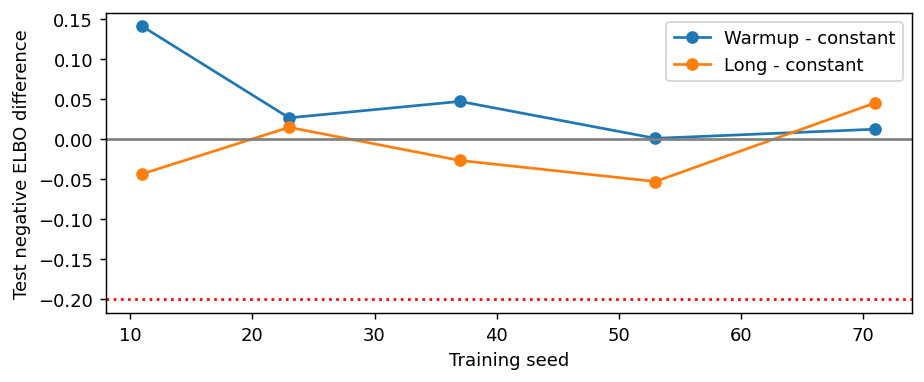

In [5]:
rows=results['paired'];fig,ax=plt.subplots(figsize=(8,3))
for key,label in [('warmup_minus_constant','Warmup - constant'),('long_minus_constant','Long - constant')]:
    ax.plot([r['seed'] for r in rows],[r[key] for r in rows],marker='o',label=label)
ax.axhline(0,color='gray');ax.axhline(-.2,color='red',ls=':')
ax.set(xlabel='Training seed',ylabel='Test negative ELBO difference');ax.legend();show(fig)

## 5 概率图和真实伯努利抽样
图中固定seed11前8例；不依据观感选择。第一排为概率，第二排为实际二值采样。

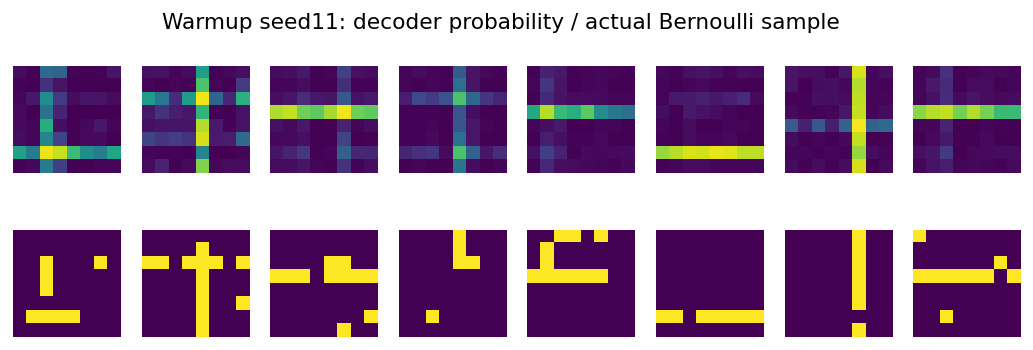

In [6]:
a=np.load('notebook_outputs/warmup_seed11_arrays.npz')
fig,axes=plt.subplots(2,8,figsize=(10,3))
for i in range(8):
    axes[0,i].imshow(a['sample_probabilities'][i].reshape(8,8),vmin=0,vmax=1,cmap='viridis')
    axes[1,i].imshow(a['samples'][i].reshape(8,8),vmin=0,vmax=1,cmap='viridis')
for ax in axes.ravel():ax.axis('off')
fig.suptitle('Warmup seed11: decoder probability / actual Bernoulli sample');show(fig)

## 6 失败样本
按保存的逐例测试NELBO排序，只用于解释，不用于回改本次模型。记录索引后可在相同数据上复查。

Failure indices: [397, 382, 504, 55, 454, 315, 404, 446]
Per-example NELBO: [32.854874 31.7398   29.837559 29.07505  28.707548 27.915504 27.680521
 27.518532]


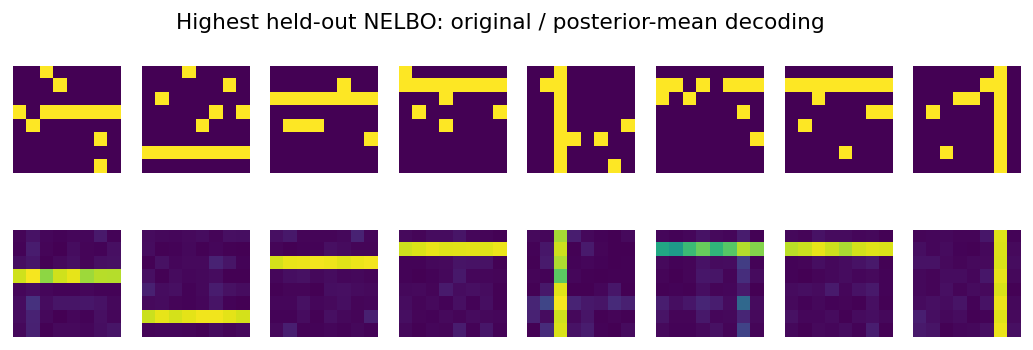

In [7]:
idx=a['failure_indices'][:8]
print('Failure indices:',idx.tolist())
print('Per-example NELBO:',a['negative_elbo'][idx])
fig,axes=plt.subplots(2,8,figsize=(10,3))
for j,i in enumerate(idx):
    axes[0,j].imshow(data['test'][i].reshape(8,8),vmin=0,vmax=1,cmap='viridis')
    axes[1,j].imshow(a['mean_reconstruction'][i].reshape(8,8),vmin=0,vmax=1,cmap='viridis')
for ax in axes.ravel():ax.axis('off')
fig.suptitle('Highest held-out NELBO: original / posterior-mean decoding');show(fig)

## 7 检查点复现
加载本Notebook实际训练出的15个检查点，重生1024样本与概率。

In [8]:
for row in results['runs']:
    key=f"{row['arm']}_seed{row['seed']}"
    c=torch.load(f'notebook_outputs/{key}.pt',weights_only=True)
    m=e.VAE();m.load_state_dict(c['state_dict']);m.eval()
    samples,probs=e.sample_model(m,c['sampling_seed'])
    saved=np.load(f'notebook_outputs/{key}_arrays.npz')
    np.testing.assert_array_equal(samples,saved['samples']);np.testing.assert_array_equal(probs,saved['sample_probabilities'])
print('All 15 checkpoints reproduce saved samples and probabilities exactly.')

All 15 checkpoints reproduce saved samples and probabilities exactly.


## 结论
当前实验不支持预热收益假设；这不是失败的研究交付。请写出机制为何在本模型中可能不成为瓶颈，哪些证据仍然缺失，下一次如何使用新验证设计而不继续消费这份测试集。